In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as base_model
from lr_model import LinearRegressor 
from sklearn.metrics import root_mean_squared_error, r2_score

In [31]:
df= pd.read_csv('../../datasets/Housing.csv', lineterminator= '\n')

In [32]:
# selection of features and labels
X = df[['area', 'bedrooms', 'bathrooms', 'stories',
        'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning'
       ]]
y= df[['price']]

In [33]:
#preprocessor for scaling columns
num_cols= ['area']
cat_cols= ['bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']

preprocessor= ColumnTransformer(
    transformers= [
        ('scaler', StandardScaler(), num_cols),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder= 'passthrough'
)

In [34]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 1243)

In [35]:
#scaling features and adding bias column
X_train= preprocessor.fit_transform(X_train)
X_train = np.c_[X_train, np.ones(X_train.shape[0])]

In [36]:
# scaling hosue prices for training
ss= StandardScaler()
y_train = ss.fit_transform(y_train)

In [37]:
#training
lr= 0.001
epochs= 50_000

model= LinearRegressor(lr)
model.fit(X_train, y_train, epochs)
W = model.get_weights()

In [38]:
# transformation for testing
X_test = preprocessor.transform(X_test)
X_test= np.c_[X_test, np.ones(X_test.shape[0])]

y_test = ss.transform(y_test)

In [39]:
#testing
y_pred = model.predict(X_test).flatten()

In [40]:
# evaluation
rmse = root_mean_squared_error(y_test.flatten(), y_pred)
r2= r2_score(y_test.flatten(), y_pred)

print(f'RMSE error: {rmse:.2f}')
print(f'R2-Score: {r2:.2f}')

RMSE error: 0.64
R2-Score: 0.58


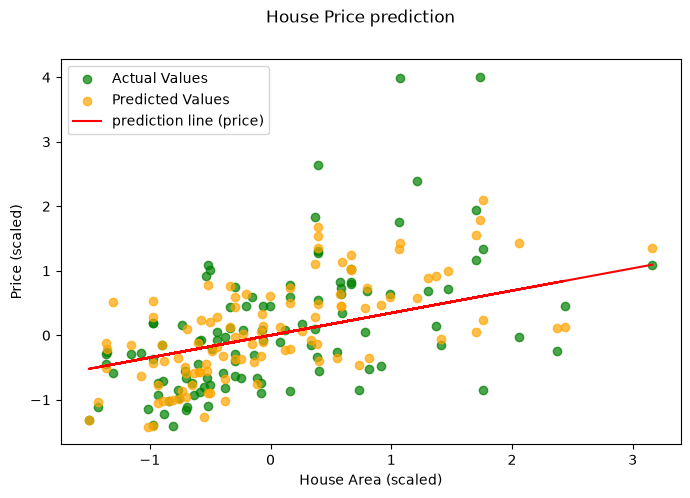

In [41]:
#plotting predicted versus actual values
x_plot= X_test[:, 0]
y_line_val= np.dot(x_plot, W[0]) 

fig= plt.figure(figsize= (8, 5))
fig.suptitle('House Price prediction')
plt.scatter(x= x_plot, y= y_test.flatten(), c= 'green', alpha= 0.7, label= 'Actual Values')
plt.scatter(x= x_plot, y= y_pred.flatten(), c= 'orange', alpha= 0.7, label= 'Predicted Values')
plt.plot(x_plot, y_line_val, color= 'red', label= 'prediction line (price)')

plt.xlabel('House Area (scaled)')
plt.ylabel('Price (scaled)')
plt.legend()
plt.show()

Text(0.5, 1.0, 'w2 vs J')

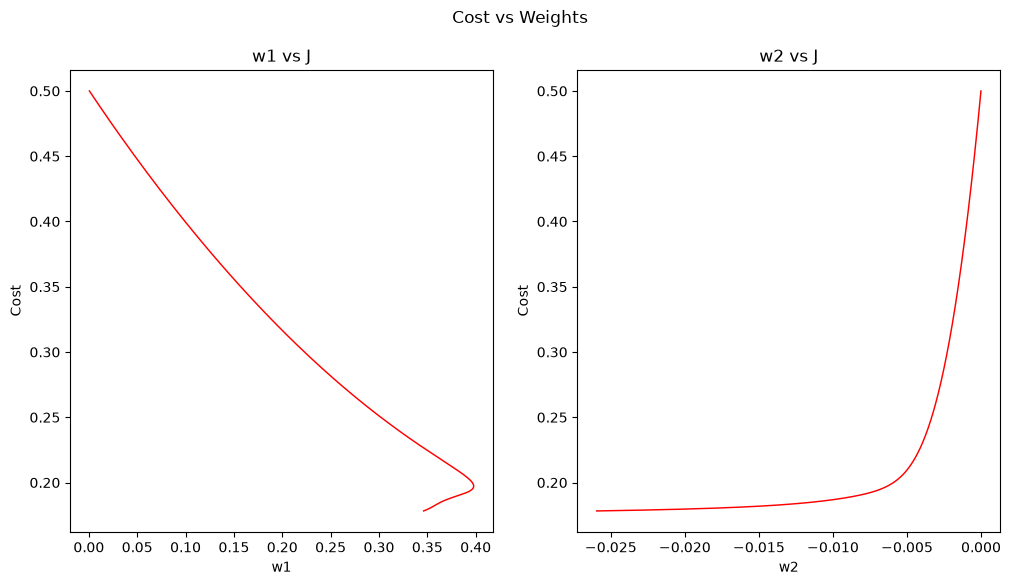

In [45]:
#plotting errors
cost_hist= np.array(model.get_cost_hist())
param_hist= np.array(model.get_param_hist())

w1, w2= param_hist[:, 0], param_hist[:, 1]
indices= np.argsort(cost_hist)

w1_sorted = w1[indices]
w2_sorted = w2[indices]
cost_sorted= cost_hist[indices]

fig, ax= plt.subplots(1, 2, figsize= (12, 6))
fig.suptitle('Cost vs Weights')

ax[0].plot(w1_sorted, cost_sorted, linewidth= 1.05, color= 'red')
ax[0].set_xlabel('w1')
ax[0].set_ylabel('Cost')
ax[0].set_title('w1 vs J')

ax[1].plot(w2_sorted, cost_sorted, linewidth= 1.05, color= 'red')
ax[1].set_xlabel('w2')
ax[1].set_ylabel('Cost')
ax[1].set_title('w2 vs J')

## Comparing with a Baseline model

In [43]:
base_lr= base_model()
base_lr.fit(X_train, y_train)

y_pred_baseline= base_lr.predict(X_test).flatten()

In [44]:
# evaluation
rmse = root_mean_squared_error(y_test.flatten(), y_pred_baseline)
r2= r2_score(y_test.flatten(), y_pred_baseline)

print(f'RMSE error: {rmse:.2f}')
print(f'R2-Score: {r2:.2f}')

RMSE error: 0.65
R2-Score: 0.56
